# HDB Resale Flat Clustering & Price Forecasting — exploration & model tuning

We segment Singapore's HDB resale market into **clusters of (town, flat-type) combinations**
that behave similarly — median price, price growth, remaining lease — so a buyer can find
towns that resemble the one they're looking at, but at a different price point.

Then we test a concrete question: **does knowing the cluster improve a price-prediction model?**
The same gradient-boosting regressor is trained twice — with and without the cluster assignment —
and compared on a temporal holdout. Either result is a legitimate finding.

| Step | What it does |
|---|---|
| 1 | Setup: libraries, parameters, fetch ~240k transactions from data.gov.sg, cache locally |
| 2 | Clean: parse remaining lease and storey range, convert types, filter sparse combos |
| 3 | Explore: price distributions by town and flat type, volume trends, feature correlations |
| 4 | Cluster (town, flat_type) groups by price behavior — K-Means, silhouette-scored |
| 5 | Forecast: gradient boosting with vs. without cluster, honest temporal backtest |
| 6 | Export: Tableau CSV + model artifacts |

**Data source (verified live):** `d_8b84c4ee58e3cfc0ece0d773c8ca6abc` — HDB resale flat prices,
from Jan 2017 onwards, one row per transaction. Published by the Housing & Development Board
via data.gov.sg.

## Step 1 — Setup

### 1.1 — Libraries

In [3]:
import json
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests


from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, silhouette_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

### 1.2 — Parameters

In [4]:
# Where to scrape the data from
DATASET_ID = "d_8b84c4ee58e3cfc0ece0d773c8ca6abc"
API_URL = "https://data.gov.sg/api/action/datastore_search"

ROOT = Path.cwd()
RAW_CSV = ROOT / "dataset" / "hdb_resale_raw.csv"

# List of flat types available in HDB
FLAT_ORDER = ["1 ROOM",
              "2 ROOM",
              "3 ROOM",
              "4 ROOM",
              "5 ROOM",
              "EXECUTIVE",
              "MULTI-GENERATION"]

# Random seed for reproducibility
SEED = 42

# Clustering
K_RANGE = range(3, 11)
MIN_TRANSACTIONS = 30

# Forecasting (Used for testing the model)
HOLDOUT_MONTHS = 6

# Parameters for Gradient Boosting
GB_PARAMS = dict(max_iter=300,
                 max_depth=6,
                 learning_rate=0.05,
                 random_state=SEED)

### 1.3 — Fetch the data

The API returns at most 1,000 rows per call, so we page through it until we have everything.
This dataset is large (~240k rows), so the fetch takes several minutes (~241 pages). If a
local CSV cache already exists, we load from that instead — delete the file to force a
fresh fetch.

In [ ]:
def fetch_all(dataset_id):
    """
    Retrieves all record in the dataset, as a DataFrame. Extract 1000 rows at a time.
    """
    records = []
    offset = 0
    while True:
        for attempt in range(5):
            response = requests.get(
                API_URL,
                params={"resource_id": dataset_id,
                        "limit": 1000,
                        "offset": offset},
                timeout=30,
            )

            # If we hit the rate limit error (429), wait a while and try again
            if response.status_code == 429:
                wait = 2 ** attempt
                print(f"  rate-limited at offset {offset}, retrying in {wait}s ...")
                time.sleep(wait)
                continue

            # This will alert us if there was any other error (e.g. 500, 404, etc.)
            response.raise_for_status()
            break

        # Parse the JSON response by adding the row from this page tot he list
        result = response.json()["result"]
        records.extend(result["records"])

        # If we extracted all the rows, exit out of loop.
        # Else just continue to the next 
        if len(records) >= result["total"]:
            break
        offset += 1000

        # Just printing out to see the progress
        if offset % 1000 == 0:
            print(f"  {len(records):,} / {result['total']:,} rows ...")
    return pd.DataFrame(records)

### Calling the data.gov.sg API seperately

Each call will be per 1000 rows:
- https://data.gov.sg/api/action/datastore_search?resource_id=d_8b84c4ee58e3cfc0ece0d773c8ca6abc&limit=1000&offset=0

- https://data.gov.sg/api/action/datastore_search?resource_id=d_8b84c4ee58e3cfc0ece0d773c8ca6abc&limit=1000&offset=1000

Do it untill all rows are collected

In [9]:
# Crate any missing parents folder. If folder already exists, don't crash.
RAW_CSV.parent.mkdir(parents=True,
                     exist_ok=True)

# Loading and read the CSV file
if RAW_CSV.exists():
#     raw = pd.read_csv(RAW_CSV)
#     print(f"loaded from cache: {RAW_CSV.relative_to(ROOT)}")
# else:
    raw = fetch_all(DATASET_ID)
    raw.to_csv(RAW_CSV,
               index=False)

    # Just tell using where the file is saved at
    print(f"Extracted to {RAW_CSV.relative_to(ROOT)}")

print(f"{len(raw):,} rows x {len(raw.columns)} columns")
raw.head(3)

  1,000 / 240,684 rows ...
  2,000 / 240,684 rows ...
  3,000 / 240,684 rows ...
  4,000 / 240,684 rows ...
  5,000 / 240,684 rows ...
  6,000 / 240,684 rows ...
  7,000 / 240,684 rows ...
  8,000 / 240,684 rows ...
  9,000 / 240,684 rows ...
  10,000 / 240,684 rows ...
  11,000 / 240,684 rows ...
  12,000 / 240,684 rows ...
  13,000 / 240,684 rows ...
  14,000 / 240,684 rows ...
  15,000 / 240,684 rows ...
  16,000 / 240,684 rows ...
  17,000 / 240,684 rows ...
  18,000 / 240,684 rows ...
  19,000 / 240,684 rows ...
  20,000 / 240,684 rows ...
  21,000 / 240,684 rows ...
  22,000 / 240,684 rows ...
  23,000 / 240,684 rows ...
  24,000 / 240,684 rows ...
  25,000 / 240,684 rows ...
  26,000 / 240,684 rows ...
  27,000 / 240,684 rows ...
  28,000 / 240,684 rows ...
  29,000 / 240,684 rows ...
  30,000 / 240,684 rows ...
  31,000 / 240,684 rows ...
  32,000 / 240,684 rows ...
  33,000 / 240,684 rows ...
  34,000 / 240,684 rows ...
  35,000 / 240,684 rows ...
  36,000 / 240,684 rows ...
 

,_id,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,1,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44,Improved,1979,61 years 04 months,232000
1,2,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67,New Generation,1978,60 years 07 months,250000
2,3,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67,New Generation,1980,62 years 05 months,262000


### 1.4 — First look

One row per resale transaction, from Jan 2017 onwards. Check the date range, the set of
towns and flat types, and that nothing looks obviously wrong.

In [11]:
# To check the date range of the dataset
min_month = raw["month"].min()
max_month = raw["month"].max()

print("date range:", min_month, "to", max_month)

date range: 2017-01 to 2026-09


In [30]:
# To see what towns are there in the dataset
towns = (raw["town"].value_counts().sort_index())
print(towns)

town
ANG MO KIO          9708
BEDOK              12554
BISHAN              4190
BUKIT BATOK        10296
BUKIT MERAH         9157
BUKIT PANJANG       8548
BUKIT TIMAH          586
CENTRAL AREA        1868
CHOA CHU KANG      10800
CLEMENTI            5314
GEYLANG             5975
HOUGANG            12155
JURONG EAST         4862
JURONG WEST        15752
KALLANG/WHAMPOA     7341
MARINE PARADE       1461
PASIR RIS           6969
PUNGGOL            17410
QUEENSTOWN          6587
SEMBAWANG           7345
SENGKANG           19466
SERANGOON           4224
TAMPINES           16700
TOA PAYOH           7930
WOODLANDS          17149
YISHUN             16337
Name: count, dtype: int64


In [29]:
# To see what flat types are available in the dataset
# flats = sorted(raw["flat_type"].unique())

flats = (raw["flat_type"].value_counts().sort_index())

print(flats)

flat_type
1 ROOM                  88
2 ROOM                5052
3 ROOM               57198
4 ROOM              102278
5 ROOM               58876
EXECUTIVE            17103
MULTI-GENERATION        89
Name: count, dtype: int64


In [34]:
# To see the how many unique combinations of town and flat type are there in the dataset

unique_towns = raw["town"].nunique()
unique_flats = raw["flat_type"].nunique()

print(f"Unique towns: {unique_towns}")
print(f"Unique flats: {unique_flats}")

Unique towns: 26
Unique flats: 7


In [5]:
hdb = raw.copy()

for col in ["resale_price", "floor_area_sqm"]:
    hdb[col] = pd.to_numeric(hdb[col], errors="coerce")

hdb["lease_commence_date"] = pd.to_numeric(hdb["lease_commence_date"], errors="coerce").astype(int)

print(hdb[["resale_price", "floor_area_sqm", "lease_commence_date"]].describe())

       resale_price  floor_area_sqm  lease_commence_date
count  2.406840e+05   240684.000000        240684.000000
mean   5.351040e+05       96.691514          1996.617050
std    1.924621e+05       24.016963            14.394469
min    1.400000e+05       31.000000          1966.000000
25%    3.900000e+05       81.000000          1985.000000
50%    5.040000e+05       93.000000          1997.000000
75%    6.418880e+05      112.000000          2012.000000
max    1.728000e+06      366.700000          2023.000000


### 2.2 — Parse remaining_lease

The column contains text like `"61 years 04 months"` or `"79 years"`. We extract a
numeric value in years (e.g., 61.33).

In [6]:
def parse_remaining_lease(text):
    """'61 years 04 months' -> 61.333, '79 years' -> 79.0"""
    parts = str(text).split()
    years = int(parts[0])
    months = int(parts[2]) if len(parts) > 2 else 0
    return years + months / 12

hdb["remaining_lease_years"] = hdb["remaining_lease"].apply(parse_remaining_lease)

print(f"range: {hdb['remaining_lease_years'].min():.1f} to {hdb['remaining_lease_years'].max():.1f} years")
print(f"nulls: {hdb['remaining_lease_years'].isna().sum()}")

range: 39.3 to 97.8 years
nulls: 0


### 2.3 — Parse storey_range

The format is always `"NN TO NN"`. We take the midpoint as a numeric feature.

In [7]:
def parse_storey_mid(text):
    """'04 TO 06' -> 5.0"""
    low, high = text.split(" TO ")
    return (int(low) + int(high)) / 2

hdb["storey_mid"] = hdb["storey_range"].apply(parse_storey_mid)

print(f"range: {hdb['storey_mid'].min():.0f} to {hdb['storey_mid'].max():.0f}")
print(f"nulls: {hdb['storey_mid'].isna().sum()}")

range: 2 to 50
nulls: 0


### 2.4 — Filter sparse (town, flat_type) combos

Not all 26 towns × 7 flat types have enough resale transactions to produce reliable
medians and growth rates. Combinations with fewer than 30 transactions are excluded
from clustering — their statistics would be driven by individual outlier sales.

In [8]:
combo_counts = hdb.groupby(["town", "flat_type"]).size().reset_index(name="n")
sparse = combo_counts[combo_counts["n"] < MIN_TRANSACTIONS]

print(f"{len(combo_counts)} total combos, {len(sparse)} with < {MIN_TRANSACTIONS} transactions:")
for _, row in sparse.iterrows():
    print(f"  x {row['town']} / {row['flat_type']}  ({row['n']} transactions)")

valid = combo_counts[combo_counts["n"] >= MIN_TRANSACTIONS]
hdb = hdb.merge(valid[["town", "flat_type"]], on=["town", "flat_type"])

print(f"\nKept {len(valid)} combos, {len(hdb):,} transactions")

131 total combos, 6 with < 30 transactions:
  x BISHAN / MULTI-GENERATION  (13 transactions)
  x BUKIT MERAH / EXECUTIVE  (3 transactions)
  x CENTRAL AREA / EXECUTIVE  (2 transactions)
  x MARINE PARADE / 2 ROOM  (9 transactions)
  x SERANGOON / 2 ROOM  (19 transactions)
  x TAMPINES / MULTI-GENERATION  (28 transactions)



Kept 125 combos, 240,610 transactions


### 2.5 — Summary after cleaning

In [9]:
print(f"{len(hdb):,} rows x {len(hdb.columns)} columns")
print(f"date range: {hdb['month'].min()} to {hdb['month'].max()}")
print(f"nulls:\n{hdb[['resale_price', 'floor_area_sqm', 'remaining_lease_years', 'storey_mid']].isna().sum()}")
print()
hdb[["month", "town", "flat_type", "floor_area_sqm", "storey_mid",
     "remaining_lease_years", "resale_price"]].sample(5, random_state=42)

240,610 rows x 14 columns
date range: 2017-01 to 2026-09
nulls:
resale_price             0
floor_area_sqm           0
remaining_lease_years    0
storey_mid               0
dtype: int64



,month,town,flat_type,floor_area_sqm,storey_mid,remaining_lease_years,resale_price
167062,2023-11,WOODLANDS,4 ROOM,93.0,5.0,93.666667,560000.0
77595,2020-08,WOODLANDS,4 ROOM,90.0,8.0,82.416667,366000.0
68112,2020-03,BUKIT MERAH,4 ROOM,93.0,5.0,94.833333,825000.0
112718,2021-11,JURONG WEST,5 ROOM,135.0,5.0,62.416667,460000.0
208871,2025-01,KALLANG/WHAMPOA,4 ROOM,92.0,8.0,94.416667,998000.0


## Step 3 — Explore

Before modelling, we look at what we're working with. Three questions:

1. **How do prices differ by flat type?** This tells us whether flat_type is a strong
   price driver (it will be — a 5-room costs more than a 2-room).
2. **How has transaction volume changed over time?** Reveals data gaps and market cycles.
3. **Do towns follow different price trajectories?** This is the motivation for clustering:
   if all towns moved together, there would be nothing to cluster.

### 3.1 — Chart style

In [10]:
def style_axis(ax):
    ax.grid(True, alpha=0.25, linestyle=":")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

price_fmt = lambda v, _: f"{v/1000:.0f}k"

CLUSTER_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4",
                  "#8b5cf6", "#06b6d4", "#f43f5e", "#84cc16", "#a3a3a3"]

### 3.2 — Price distribution by flat type

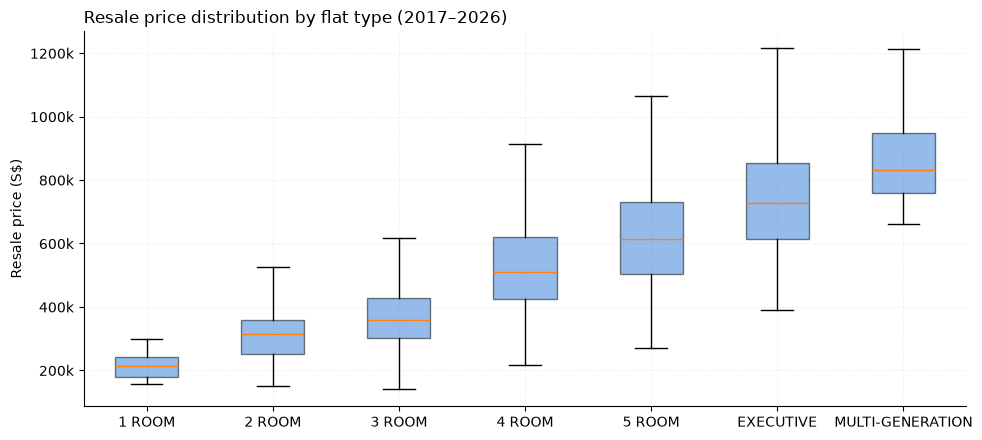

In [11]:
flat_order_present = [ft for ft in FLAT_ORDER if ft in hdb["flat_type"].unique()]

fig, ax = plt.subplots(figsize=(10, 4.5))
data = [hdb.loc[hdb["flat_type"] == ft, "resale_price"].values for ft in flat_order_present]
bp = ax.boxplot(data, tick_labels=flat_order_present, patch_artist=True, showfliers=False)
for patch in bp["boxes"]:
    patch.set_facecolor("#2a78d6")
    patch.set_alpha(0.5)

ax.set_title("Resale price distribution by flat type (2017–2026)", loc="left")
ax.set_ylabel("Resale price (S$)")
ax.yaxis.set_major_formatter(price_fmt)
style_axis(ax)
plt.tight_layout()
plt.show()

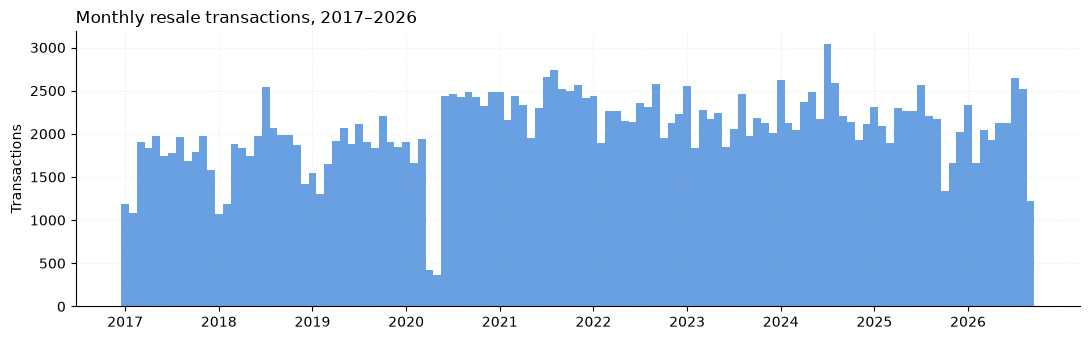

In [12]:
monthly_vol = hdb.groupby("month").size()

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.bar(range(len(monthly_vol)), monthly_vol.values, color="#2a78d6", alpha=0.7, width=1.0)
tick_idx = list(range(0, len(monthly_vol), 12))
ax.set_xticks(tick_idx)
ax.set_xticklabels([monthly_vol.index[i][:4] for i in tick_idx])
ax.set_title("Monthly resale transactions, 2017–2026", loc="left")
ax.set_ylabel("Transactions")
style_axis(ax)
plt.tight_layout()
plt.show()

### 3.4 — Median price over time, selected towns

We plot the six most-traded towns to see whether price trajectories diverge —
which is the whole motivation for clustering.

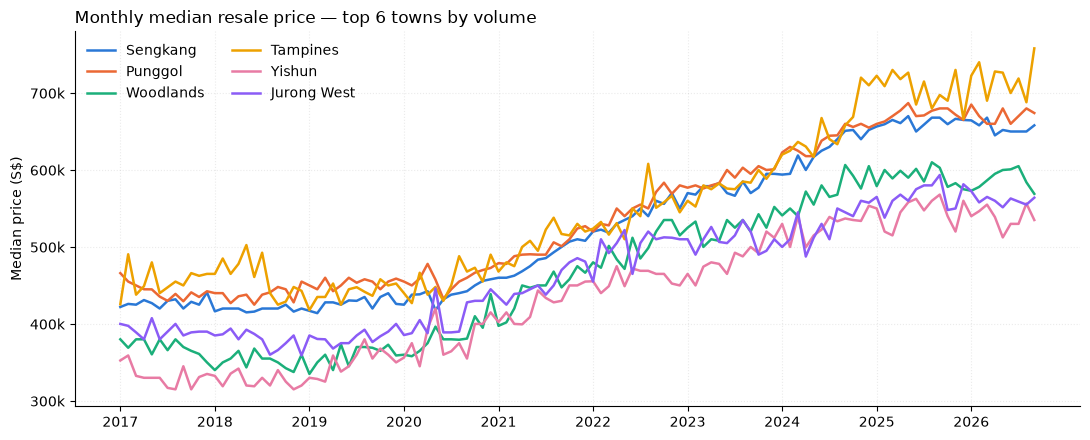

In [13]:
top_towns = hdb["town"].value_counts().head(6).index.tolist()
town_colors = dict(zip(top_towns, CLUSTER_COLORS))

fig, ax = plt.subplots(figsize=(11, 4.5))
for town in top_towns:
    monthly = hdb.loc[hdb["town"] == town].groupby("month")["resale_price"].median()
    ax.plot(range(len(monthly)), monthly.values, linewidth=1.8,
            color=town_colors[town], label=town.title())

tick_idx = list(range(0, len(monthly), 12))
ax.set_xticks(tick_idx)
ax.set_xticklabels([monthly.index[i][:4] for i in tick_idx])
ax.set_title("Monthly median resale price — top 6 towns by volume", loc="left")
ax.set_ylabel("Median price (S$)")
ax.yaxis.set_major_formatter(price_fmt)
ax.legend(frameon=False, loc="upper left", ncol=2)
style_axis(ax)
plt.tight_layout()
plt.show()

## Step 4 — Clustering

Cluster at the **(town, flat_type) aggregation level**, not per individual transaction.
Clustering every single sale would mostly just rediscover "expensive sales vs. cheap sales",
which isn't a useful grouping. Aggregating first — one row per town + flat-type combination,
with features like median price, price growth rate, and remaining lease — is what produces
meaningful "neighborhood A behaves like neighborhood B" groups.

### 4.1 — Aggregate to (town, flat_type)

In [14]:
def compute_cluster_features(hdb):
    """One row per (town, flat_type) with median price, growth rate, avg remaining lease."""
    group = hdb.groupby(["town", "flat_type"])
    medians = group["resale_price"].median().rename("median_price")
    lease = group["remaining_lease_years"].mean().rename("avg_remaining_lease")
    counts = group.size().rename("transaction_count")

    all_months = sorted(hdb["month"].unique())
    midpoint = all_months[len(all_months) // 2]
    earlier = hdb[hdb["month"] <= midpoint].groupby(["town", "flat_type"])["resale_price"].median()
    recent = hdb[hdb["month"] > midpoint].groupby(["town", "flat_type"])["resale_price"].median()
    growth = ((recent - earlier) / earlier).rename("growth_rate")

    features = pd.concat([medians, growth, lease, counts], axis=1)
    features["growth_rate"] = features["growth_rate"].fillna(0.0)
    return features.reset_index()

cluster_df = compute_cluster_features(hdb)
print(f"{len(cluster_df)} (town, flat_type) combinations")
print()
print(cluster_df[["median_price", "growth_rate", "avg_remaining_lease"]].describe().round(2))
print()
cluster_df.head(5)

125 (town, flat_type) combinations

       median_price  growth_rate  avg_remaining_lease
count        125.00       125.00               125.00
mean      550223.91         0.34                72.30
std       213131.54         0.11                11.43
min       212500.00         0.00                49.26
25%       357000.00         0.27                65.18
50%       525000.00         0.34                72.06
75%       720000.00         0.41                78.80
max      1080000.00         0.63                93.97



,town,flat_type,median_price,growth_rate,avg_remaining_lease,transaction_count
0,ANG MO KIO,2 ROOM,266000.0,0.428571,57.429029,182
1,ANG MO KIO,3 ROOM,350000.0,0.359060,58.740361,5127
2,ANG MO KIO,4 ROOM,516000.0,0.337209,67.104973,2815
3,ANG MO KIO,5 ROOM,745000.0,0.269380,71.071758,1447
4,ANG MO KIO,EXECUTIVE,920000.0,0.271956,66.113747,137


### 4.2 — Scale features for K-Means

K-Means uses Euclidean distance, so features must be scaled. Without scaling, median prices
in the hundreds of thousands would dominate growth rates in the 0.1–0.5 range.

In [15]:
feature_cols = ["median_price", "growth_rate", "avg_remaining_lease"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df[feature_cols])

print(f"scaled shape: {X_scaled.shape}")
print(f"means after scaling: {X_scaled.mean(axis=0).round(4)}")
print(f"stds after scaling:  {X_scaled.std(axis=0).round(4)}")

scaled shape: (125, 3)
means after scaling: [-0. -0.  0.]
stds after scaling:  [1. 1. 1.]


### 4.3 — K-Means: test k = 3 through 10

Silhouette score measures how well each point fits its own cluster vs. the nearest other
cluster (range −1 to 1, higher is better). We test every k and pick the best, then
sanity-check whether the groupings make real-world sense.

In [16]:
def find_best_k(X, k_range):
    """Fit K-Means for each k, return a DataFrame of k vs silhouette score."""
    rows = []
    for k in k_range:
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        labels = km.fit_predict(X)
        score = silhouette_score(X, labels)
        rows.append({"k": k, "silhouette": round(score, 4)})
    return pd.DataFrame(rows)

k_scores = find_best_k(X_scaled, K_RANGE)
print(k_scores.to_string(index=False))

 k  silhouette
 3      0.4010
 4      0.3550
 5      0.3516
 6      0.3285
 7      0.3229
 8      0.3245
 9      0.3166
10      0.3021


### 4.4 — Silhouette plot

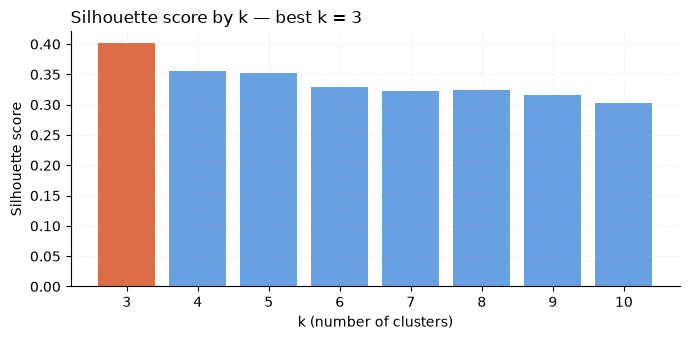


Best k = 3  (silhouette = 0.401)


In [17]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(k_scores["k"], k_scores["silhouette"], color="#2a78d6", alpha=0.7)

best_k = int(k_scores.loc[k_scores["silhouette"].idxmax(), "k"])
ax.bar(best_k, k_scores.loc[k_scores["k"] == best_k, "silhouette"].values[0],
       color="#eb6834", alpha=0.9)

ax.set_xlabel("k (number of clusters)")
ax.set_ylabel("Silhouette score")
ax.set_title(f"Silhouette score by k — best k = {best_k}", loc="left")
ax.set_xticks(list(K_RANGE))
style_axis(ax)
plt.tight_layout()
plt.show()

print(f"\nBest k = {best_k}  (silhouette = {k_scores.loc[k_scores['k'] == best_k, 'silhouette'].values[0]})")

### 4.5 — Fit the winning k and sanity-check

The statistically best k must also produce groupings that make real-world sense.
Do mature estates cluster together? Do newer towns group separately? If the groupings
are nonsensical, that mismatch is worth flagging rather than accepting blindly.

In [18]:
km_final = KMeans(n_clusters=best_k, n_init=10, random_state=42)
cluster_df["cluster_id"] = km_final.fit_predict(X_scaled)

# Assign labels dynamically by median price so they survive cluster-ID renumbering
rank = cluster_df.groupby("cluster_id")["median_price"].median().rank().astype(int)
LABEL_BY_RANK = {1: "Mature & Affordable", 2: "Newer, High-Growth", 3: "Premium"}
CLUSTER_LABELS = {cid: LABEL_BY_RANK[r] for cid, r in rank.items()}
cluster_df["cluster_name"] = cluster_df["cluster_id"].map(CLUSTER_LABELS)

for cid in sorted(cluster_df["cluster_id"].unique()):
    members = cluster_df[cluster_df["cluster_id"] == cid]
    print(f"\n--- Cluster {cid}: {CLUSTER_LABELS[cid]} ({len(members)} combos) ---")
    print(f"  median price:        ${members['median_price'].median():,.0f}")
    print(f"  growth rate:         {members['growth_rate'].median():.1%}")
    print(f"  avg remaining lease: {members['avg_remaining_lease'].median():.1f} years")
    print(f"  towns: {sorted(members['town'].unique())}")
    print(f"  flat types: {sorted(members['flat_type'].unique())}")


--- Cluster 0: Premium (42 combos) ---
  median price:        $799,500
  growth rate:         26.8%
  avg remaining lease: 68.8 years
  towns: ['ANG MO KIO', 'BEDOK', 'BISHAN', 'BUKIT BATOK', 'BUKIT MERAH', 'BUKIT PANJANG', 'BUKIT TIMAH', 'CENTRAL AREA', 'CLEMENTI', 'GEYLANG', 'HOUGANG', 'JURONG EAST', 'JURONG WEST', 'KALLANG/WHAMPOA', 'MARINE PARADE', 'PASIR RIS', 'QUEENSTOWN', 'SERANGOON', 'TAMPINES', 'TOA PAYOH', 'YISHUN']
  flat types: ['2 ROOM', '4 ROOM', '5 ROOM', 'EXECUTIVE', 'MULTI-GENERATION']

--- Cluster 1: Newer, High-Growth (53 combos) ---
  median price:        $462,500
  growth rate:         41.2%
  avg remaining lease: 79.0 years
  towns: ['BUKIT BATOK', 'BUKIT PANJANG', 'CHOA CHU KANG', 'CLEMENTI', 'HOUGANG', 'JURONG EAST', 'JURONG WEST', 'KALLANG/WHAMPOA', 'PASIR RIS', 'PUNGGOL', 'SEMBAWANG', 'SENGKANG', 'TAMPINES', 'TOA PAYOH', 'WOODLANDS', 'YISHUN']
  flat types: ['2 ROOM', '3 ROOM', '4 ROOM', '5 ROOM', 'EXECUTIVE']

--- Cluster 2: Mature & Affordable (30 combos) -

### 4.6 — Cluster visualization

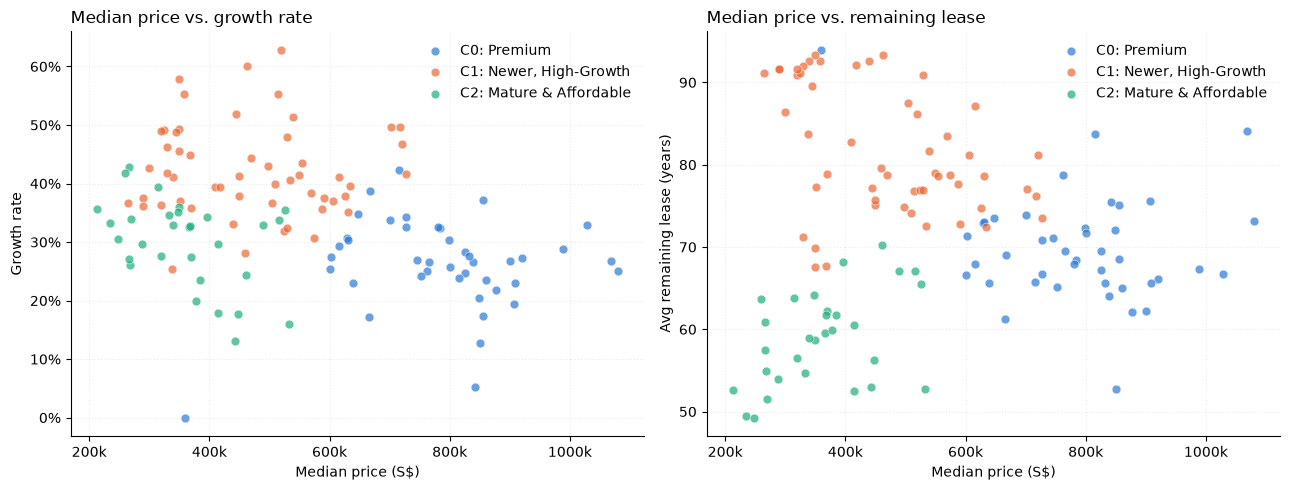

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for cid in sorted(cluster_df["cluster_id"].unique()):
    mask = cluster_df["cluster_id"] == cid
    color = CLUSTER_COLORS[cid]
    label = f"C{cid}: {CLUSTER_LABELS[cid]}"

    axes[0].scatter(cluster_df.loc[mask, "median_price"],
                    cluster_df.loc[mask, "growth_rate"],
                    c=color, label=label, s=40, alpha=0.7, edgecolors="white", linewidth=0.5)
    axes[1].scatter(cluster_df.loc[mask, "median_price"],
                    cluster_df.loc[mask, "avg_remaining_lease"],
                    c=color, label=label, s=40, alpha=0.7, edgecolors="white", linewidth=0.5)

axes[0].set_xlabel("Median price (S$)")
axes[0].set_ylabel("Growth rate")
axes[0].set_title("Median price vs. growth rate", loc="left")
axes[0].xaxis.set_major_formatter(price_fmt)
axes[0].yaxis.set_major_formatter(lambda v, p: f"{v:.0%}")
axes[0].legend(frameon=False)

axes[1].set_xlabel("Median price (S$)")
axes[1].set_ylabel("Avg remaining lease (years)")
axes[1].set_title("Median price vs. remaining lease", loc="left")
axes[1].xaxis.set_major_formatter(price_fmt)
axes[1].legend(frameon=False)

for ax in axes:
    style_axis(ax)

plt.tight_layout()
plt.show()

### 4.7 — Cluster stability analysis

K-Means depends on random initialization. If changing the seed puts different combos
into different clusters, the groupings are not trustworthy. We run K-Means 20 times with
different seeds and measure how consistently each pair of combos lands in the same cluster.

A **co-assignment rate** of 1.0 means two combos always cluster together; 0.0 means never.
High average co-assignment (>0.85) indicates stable clusters.

Mean pairwise co-assignment: 0.345  (1.0 = perfectly stable)


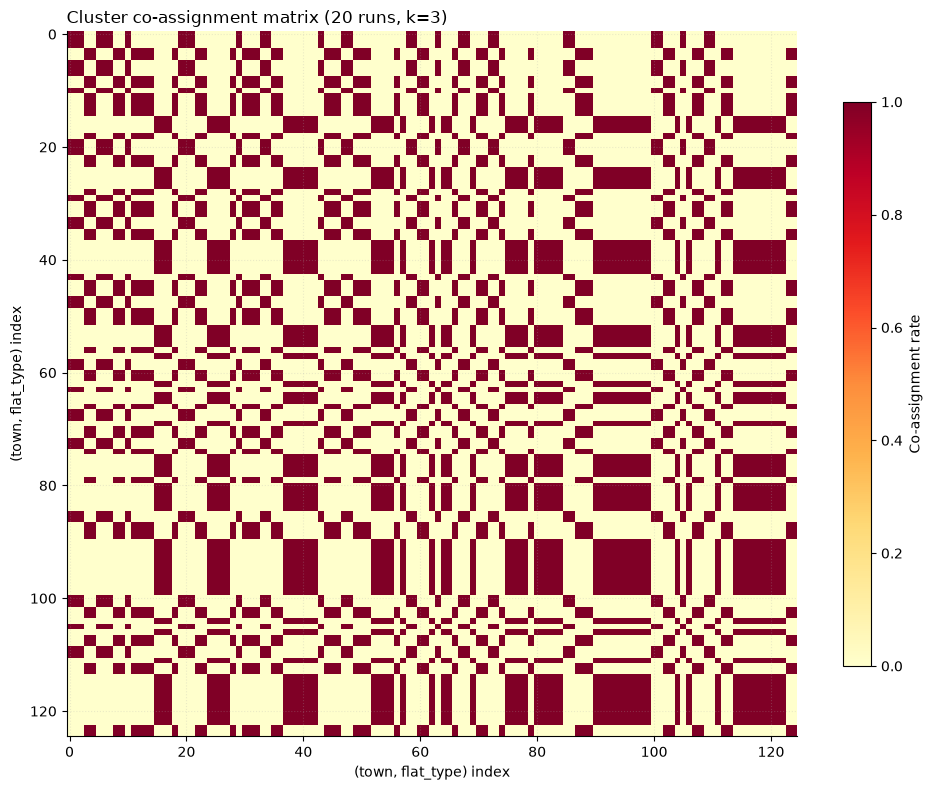


No borderline pairs — all combos consistently co-assigned.


In [20]:
N_STABILITY_RUNS = 20
n = len(X_scaled)
coassign = np.zeros((n, n))

for seed in range(N_STABILITY_RUNS):
    km = KMeans(n_clusters=best_k, n_init=10, random_state=seed)
    labels = km.fit_predict(X_scaled)
    coassign += (labels[:, None] == labels[None, :])

coassign /= N_STABILITY_RUNS

mask_upper = np.triu_indices(n, k=1)
mean_stability = float(coassign[mask_upper].mean())
print(f"Mean pairwise co-assignment: {mean_stability:.3f}  (1.0 = perfectly stable)")

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(coassign, cmap="YlOrRd", vmin=0, vmax=1, aspect="auto")
fig.colorbar(im, ax=ax, label="Co-assignment rate", shrink=0.8)
ax.set_title(f"Cluster co-assignment matrix ({N_STABILITY_RUNS} runs, k={best_k})", loc="left")
ax.set_xlabel("(town, flat_type) index")
ax.set_ylabel("(town, flat_type) index")
style_axis(ax)
plt.tight_layout()
plt.show()

upper_vals = coassign[mask_upper]
unstable_mask = (upper_vals > 0.3) & (upper_vals < 0.7)
if unstable_mask.any():
    ui, uj = mask_upper[0][unstable_mask], mask_upper[1][unstable_mask]
    unstable_pairs = sorted(zip(
        [f"{cluster_df.iloc[i]['town']} / {cluster_df.iloc[i]['flat_type']}" for i in ui],
        [f"{cluster_df.iloc[j]['town']} / {cluster_df.iloc[j]['flat_type']}" for j in uj],
        upper_vals[unstable_mask],
    ), key=lambda x: x[2])
    print(f"\n{len(unstable_pairs)} borderline pair(s) (co-assignment 30-70%):")
    for a, b, rate in unstable_pairs[:10]:
        print(f"  {rate:.0%}  {a}  <->  {b}")
else:
    print("\nNo borderline pairs — all combos consistently co-assigned.")

## Step 5 — Forecasting: with vs. without cluster

The project's differentiator. We train the same gradient-boosting model twice — once with
the cluster assignment as a feature, once without — and compare accuracy on a temporal
holdout. The methodology mirrors the COE project's honest backtest: the holdout is defined
BEFORE any model fitting, and the same spec is used for both variants.

### 5.1 — Why gradient boosting, not SARIMAX

The COE project used SARIMAX because it had one aggregated time series per category (~400
observations). HDB has ~240k individual transactions, each with property-level features
(floor area, storey, lease, location). This is a cross-sectional regression problem:
given a property's characteristics, predict its price. `HistGradientBoostingRegressor` is
the natural choice — it handles large datasets efficiently and makes the with/without-cluster
comparison straightforward (add or remove one feature column).

### 5.2 — Feature engineering

In [21]:
df = hdb.copy()

# Time features
df["year"] = df["month"].str[:4].astype(int)
df["month_num"] = df["month"].str[5:7].astype(int)
df["trend"] = (pd.to_datetime(df["month"]) - pd.Timestamp("2017-01-01")).dt.days / 365.25

# Encode categoricals as integers
town_enc = LabelEncoder()
df["town_enc"] = town_enc.fit_transform(df["town"])

flat_map = {ft: i for i, ft in enumerate(FLAT_ORDER)}
df["flat_type_enc"] = df["flat_type"].map(flat_map)

# Join cluster assignment (inner merge — no NaNs)
df = df.merge(cluster_df[["town", "flat_type", "cluster_id"]], on=["town", "flat_type"])

base_cols = ["floor_area_sqm", "remaining_lease_years", "storey_mid",
             "town_enc", "flat_type_enc", "year", "month_num", "trend"]
cluster_cols = base_cols + ["cluster_id"]

y = df["resale_price"].values

print(f"features (base): {len(base_cols)} columns")
print(f"features (with cluster): {len(cluster_cols)} columns")
print(f"target: resale_price, {len(y):,} rows")

features (base): 8 columns
features (with cluster): 9 columns
target: resale_price, 240,610 rows


### 5.3 — Temporal train/holdout split

A random split would let the model train on 2026 transactions and "predict" other 2026
transactions in the test set — that is leakage. The temporal split ensures the model only
trains on the past and predicts the future, which is the real question.

In [22]:
all_months = sorted(df["month"].unique())
cutoff = all_months[-HOLDOUT_MONTHS]

train_mask = df["month"] < cutoff
test_mask = df["month"] >= cutoff

print(f"cutoff:  {cutoff}")
print(f"train:   {train_mask.sum():,} transactions (before {cutoff})")
print(f"test:    {test_mask.sum():,} transactions ({cutoff} onwards)")

cutoff:  2026-04
train:   228,036 transactions (before 2026-04)
test:    12,574 transactions (2026-04 onwards)


### 5.4 — Train the same model, with and without cluster

Same model, same hyperparameters, same features except for the cluster_id column.
The only difference is whether the model knows which cluster each property's (town,
flat_type) combination belongs to.

In [23]:
def train_and_evaluate(X_train, y_train, X_test, y_test, label):
    """Fit HistGradientBoostingRegressor, return predictions and metrics."""
    model = HistGradientBoostingRegressor(**GB_PARAMS)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = root_mean_squared_error(y_test, preds)
    mape = float((np.abs(preds - y_test) / y_test).mean() * 100)
    print(f"{label}:  MAE ${mae:,.0f}  |  RMSE ${rmse:,.0f}  |  MAPE {mape:.2f}%")
    return model, preds, {"mae": round(float(mae), 2), "rmse": round(float(rmse), 2), "mape": round(mape, 2)}

X_base = df[base_cols].values
X_cluster = df[cluster_cols].values

model_base, preds_base, metrics_base = train_and_evaluate(
    X_base[train_mask], y[train_mask], X_base[test_mask], y[test_mask],
    "without cluster")

model_cluster, preds_cluster, metrics_cluster = train_and_evaluate(
    X_cluster[train_mask], y[train_mask], X_cluster[test_mask], y[test_mask],
    "with cluster   ")

without cluster:  MAE $44,555  |  RMSE $63,761  |  MAPE 6.58%


with cluster   :  MAE $43,067  |  RMSE $60,962  |  MAPE 6.39%


### 5.5 — The verdict

In [24]:
comparison = pd.DataFrame({
    "without cluster": metrics_base,
    "with cluster": metrics_cluster,
}).T

print("Holdout metrics (temporal split, last", HOLDOUT_MONTHS, "months):")
print(comparison.to_string())

improvement_mae = (metrics_base["mae"] - metrics_cluster["mae"]) / metrics_base["mae"] * 100
print(f"\nCluster feature {'improves' if improvement_mae > 0 else 'does not improve'} "
      f"MAE by {abs(improvement_mae):.2f}%")

Holdout metrics (temporal split, last 6 months):
                      mae      rmse  mape
without cluster  44555.42  63760.87  6.58
with cluster     43067.14  60962.15  6.39

Cluster feature improves MAE by 3.34%


### 5.6 — Predicted vs. actual

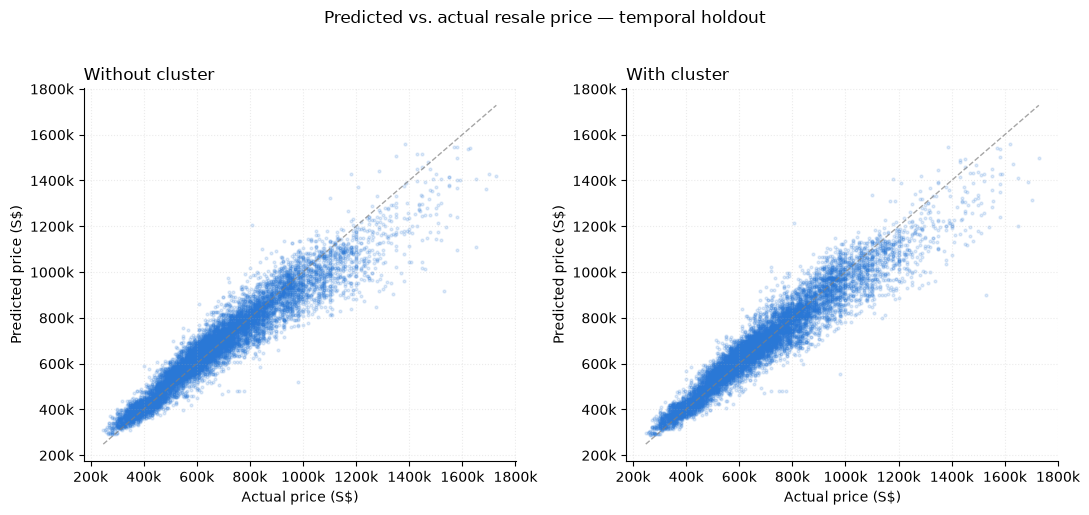

In [25]:
y_test = y[test_mask]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, preds, title in [(axes[0], preds_base, "Without cluster"),
                          (axes[1], preds_cluster, "With cluster")]:
    ax.scatter(y_test, preds, s=4, alpha=0.15, color="#2a78d6")
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lims, lims, "--", color="gray", linewidth=1, alpha=0.7)
    ax.set_xlabel("Actual price (S$)")
    ax.set_ylabel("Predicted price (S$)")
    ax.set_title(title, loc="left")
    ax.xaxis.set_major_formatter(price_fmt)
    ax.yaxis.set_major_formatter(price_fmt)
    style_axis(ax)

plt.suptitle("Predicted vs. actual resale price — temporal holdout", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### 5.7 — Error distribution by cluster

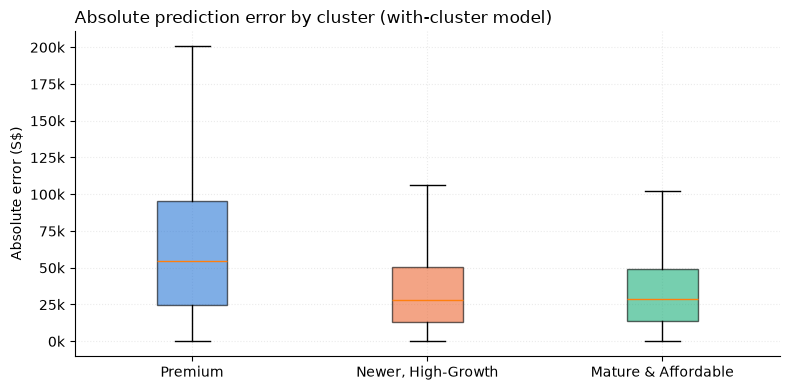

In [26]:
test_df = df[test_mask].copy()
test_df["abs_error"] = np.abs(preds_cluster - y_test)

cluster_ids = sorted(test_df["cluster_id"].unique())
fig, ax = plt.subplots(figsize=(8, 4))
data = [test_df.loc[test_df["cluster_id"] == cid, "abs_error"].values for cid in cluster_ids]
bp = ax.boxplot(data, tick_labels=[CLUSTER_LABELS[c] for c in cluster_ids],
                patch_artist=True, showfliers=False)
for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor(CLUSTER_COLORS[cluster_ids[i]])
    patch.set_alpha(0.6)

ax.set_title("Absolute prediction error by cluster (with-cluster model)", loc="left")
ax.set_ylabel("Absolute error (S$)")
ax.yaxis.set_major_formatter(price_fmt)
style_axis(ax)
plt.tight_layout()
plt.show()

## Step 6 — Export

### 6.1 — Tableau CSV

One flat file with cluster assignments, features, and latest median prices — ready
for Tableau Public upload.

In [27]:
latest_month = hdb["month"].max()
latest_medians = (hdb[hdb["month"] == latest_month]
                  .groupby(["town", "flat_type"])["resale_price"]
                  .median()
                  .rename("latest_median_price"))

tableau = cluster_df.merge(latest_medians, on=["town", "flat_type"], how="left")

TABLEAU_CSV = ROOT / "dataset" / "hdb_tableau_export.csv"
tableau.to_csv(TABLEAU_CSV, index=False)
print(f"saved {TABLEAU_CSV.relative_to(ROOT)}  ({len(tableau)} rows)")
print()
tableau.head()

saved dataset/hdb_tableau_export.csv  (125 rows)



,town,flat_type,median_price,growth_rate,avg_remaining_lease,transaction_count,cluster_id,cluster_name,latest_median_price
0,ANG MO KIO,2 ROOM,266000.0,0.428571,57.429029,182,2,Mature & Affordable,303000.0
1,ANG MO KIO,3 ROOM,350000.0,0.359060,58.740361,5127,2,Mature & Affordable,405000.0
2,ANG MO KIO,4 ROOM,516000.0,0.337209,67.104973,2815,2,Mature & Affordable,570000.0
3,ANG MO KIO,5 ROOM,745000.0,0.269380,71.071758,1447,0,Premium,940000.0
4,ANG MO KIO,EXECUTIVE,920000.0,0.271956,66.113747,137,0,Premium,1090000.0


### 6.2 — Model artifacts JSON

In [28]:
artifacts = {
    "generated": pd.Timestamp.now().isoformat(timespec="seconds"),
    "data_source": DATASET_ID,
    "total_transactions": int(len(hdb)),
    "date_range": [hdb["month"].min(), hdb["month"].max()],
    "clustering": {
        "k": int(best_k),
        "silhouette_score": float(k_scores.loc[k_scores["k"] == best_k, "silhouette"].values[0]),
        "stability_score": mean_stability,
        "stability_runs": N_STABILITY_RUNS,
        "features": feature_cols,
        "n_combos": len(cluster_df),
        "cluster_labels": CLUSTER_LABELS,
        "cluster_sizes": cluster_df["cluster_id"].value_counts().sort_index().to_dict(),
    },
    "forecasting": {
        "model": "HistGradientBoostingRegressor",
        "holdout_months": HOLDOUT_MONTHS,
        "holdout_transactions": int(test_mask.sum()),
        "without_cluster": metrics_base,
        "with_cluster": metrics_cluster,
    },
}

ARTIFACTS_JSON = ROOT / "dataset" / "model_artifacts.json"
with open(ARTIFACTS_JSON, "w") as f:
    json.dump(artifacts, f, indent=2)

print(f"saved {ARTIFACTS_JSON.relative_to(ROOT)}")
print()
print(json.dumps(artifacts, indent=2))

saved dataset/model_artifacts.json

{
  "generated": "2026-09-18T20:22:34",
  "data_source": "d_8b84c4ee58e3cfc0ece0d773c8ca6abc",
  "total_transactions": 240610,
  "date_range": [
    "2017-01",
    "2026-09"
  ],
  "clustering": {
    "k": 3,
    "silhouette_score": 0.401,
    "stability_score": 0.34503225806451615,
    "stability_runs": 20,
    "features": [
      "median_price",
      "growth_rate",
      "avg_remaining_lease"
    ],
    "n_combos": 125,
    "cluster_labels": {
      "0": "Premium",
      "1": "Newer, High-Growth",
      "2": "Mature & Affordable"
    },
    "cluster_sizes": {
      "0": 42,
      "1": 53,
      "2": 30
    }
  },
  "forecasting": {
    "model": "HistGradientBoostingRegressor",
    "holdout_months": 6,
    "holdout_transactions": 12574,
    "without_cluster": {
      "mae": 44555.42,
      "rmse": 63760.87,
      "mape": 6.58
    },
    "with_cluster": {
      "mae": 43067.14,
      "rmse": 60962.15,
      "mape": 6.39
    }
  }
}
